In [4]:
df['Reason'] = df['title'].apply(
    lambda x: x.split(':')[0]
)

df['Reason'].value_counts()

Reason
EMS        332692
Traffic    230208
Fire       100622
Name: count, dtype: int64

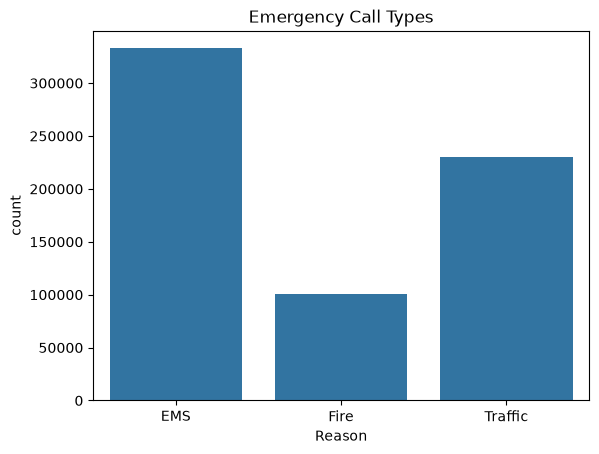

In [5]:
sns.countplot(
    data=df,
    x='Reason'
)

plt.title("Emergency Call Types")
plt.show()

In [6]:
df['timeStamp'] = pd.to_datetime(
    df['timeStamp']
)

df['timeStamp'].head()

0   2015-12-10 17:10:52
1   2015-12-10 17:29:21
2   2015-12-10 14:39:21
3   2015-12-10 16:47:36
4   2015-12-10 16:56:52
Name: timeStamp, dtype: datetime64[us]

In [7]:
df['Hour'] = df['timeStamp'].dt.hour
df['Month'] = df['timeStamp'].dt.month
df['Day'] = df['timeStamp'].dt.day_name()

df[['Hour','Month','Day']].head()

,Hour,Month,Day
0,17,12,Thursday
1,17,12,Thursday
2,14,12,Thursday
3,16,12,Thursday
4,16,12,Thursday


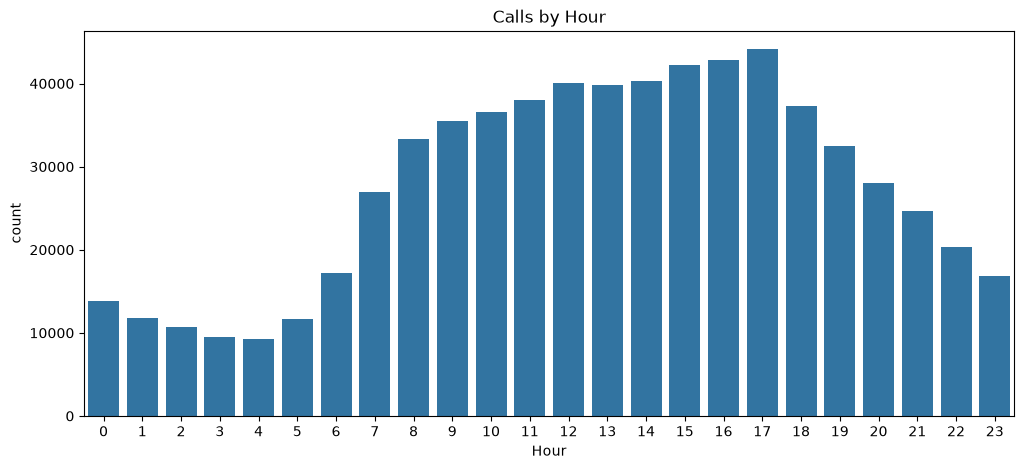

In [8]:
plt.figure(figsize=(12,5))

sns.countplot(
    data=df,
    x='Hour'
)

plt.title("Calls by Hour")

plt.show()

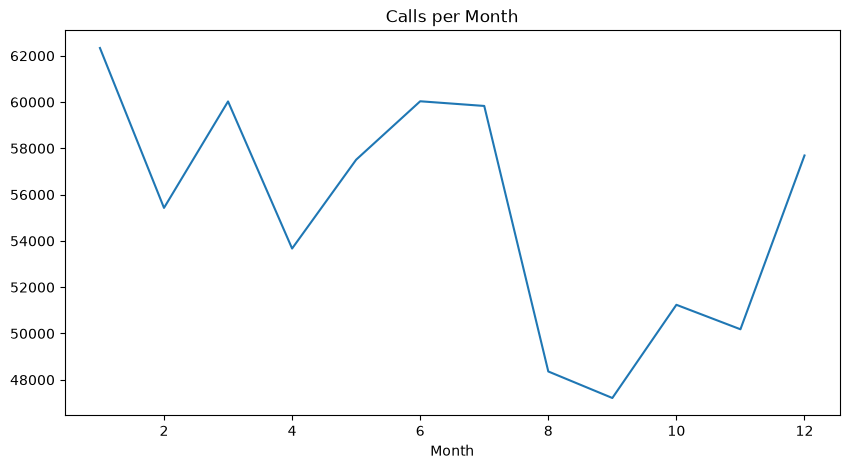

In [9]:
monthly = df.groupby('Month').size()

monthly.plot(
    figsize=(10,5)
)

plt.title("Calls per Month")

plt.show()

In [2]:
df.columns

Index(['lat', 'lng', 'desc', 'zip', 'title', 'timeStamp', 'twp', 'addr', 'e'], dtype='str')

In [11]:
day_hour = df.groupby(
    ['Day','Hour']
).size().unstack()

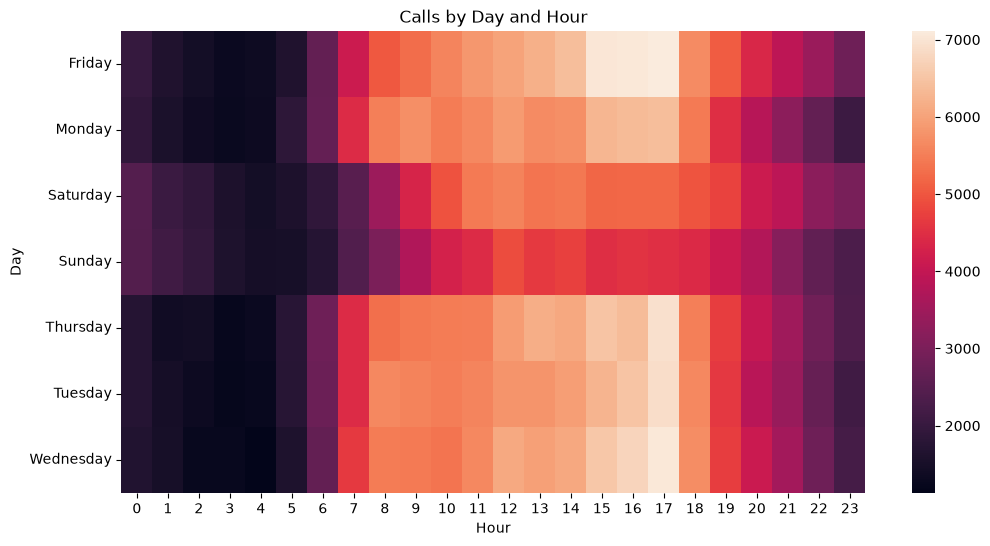

In [12]:
plt.figure(figsize=(12,6))

sns.heatmap(day_hour)

plt.title("Calls by Day and Hour")

plt.show()

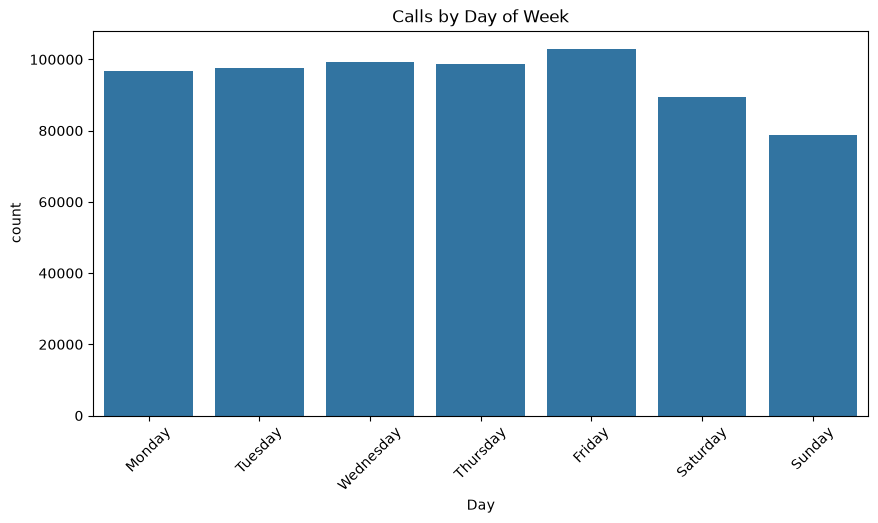

In [14]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='Day',
    order=['Monday','Tuesday','Wednesday',
           'Thursday','Friday','Saturday','Sunday']
)

plt.title("Calls by Day of Week")
plt.xticks(rotation=45)
plt.show()

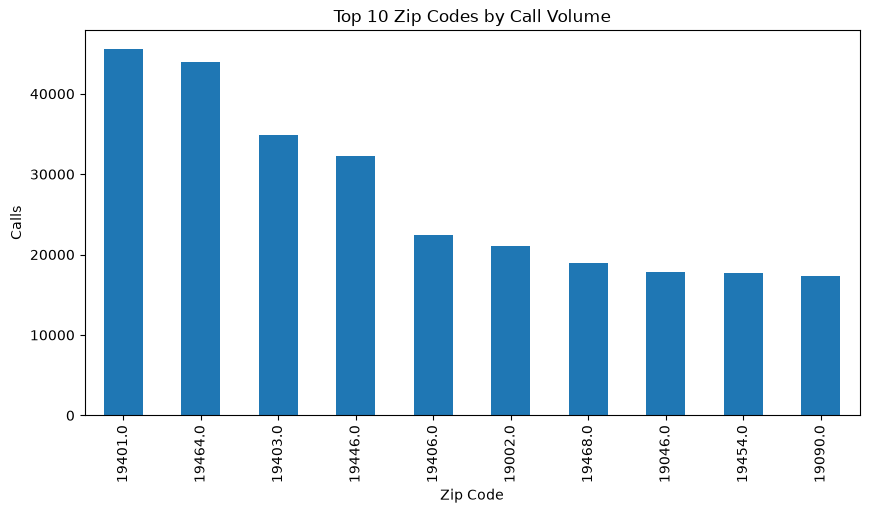

In [15]:
top_zip = df['zip'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_zip.plot(kind='bar')

plt.title("Top 10 Zip Codes by Call Volume")
plt.xlabel("Zip Code")
plt.ylabel("Calls")
plt.show()

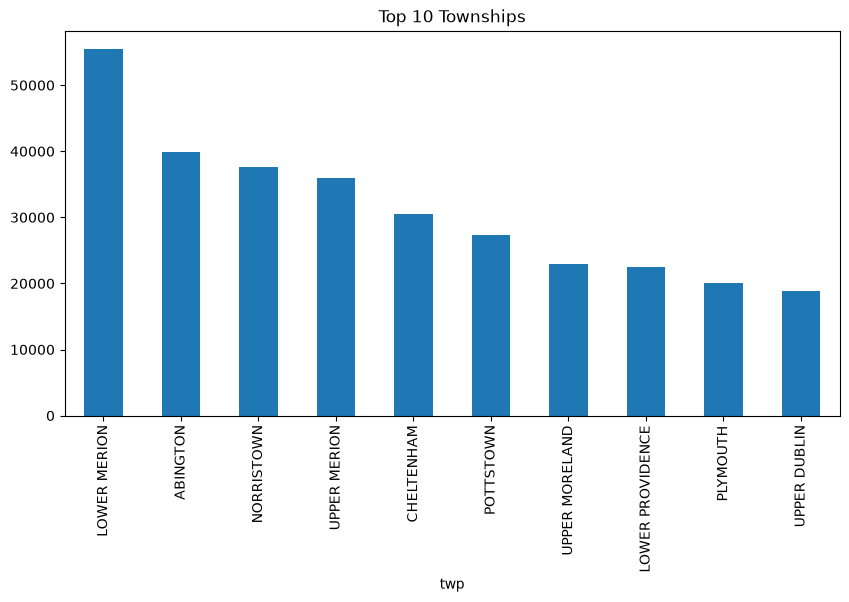

In [16]:
top_twp = df['twp'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_twp.plot(kind='bar')

plt.title("Top 10 Townships")
plt.show()

In [17]:
plt.savefig(
    "../charts/heatmap.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

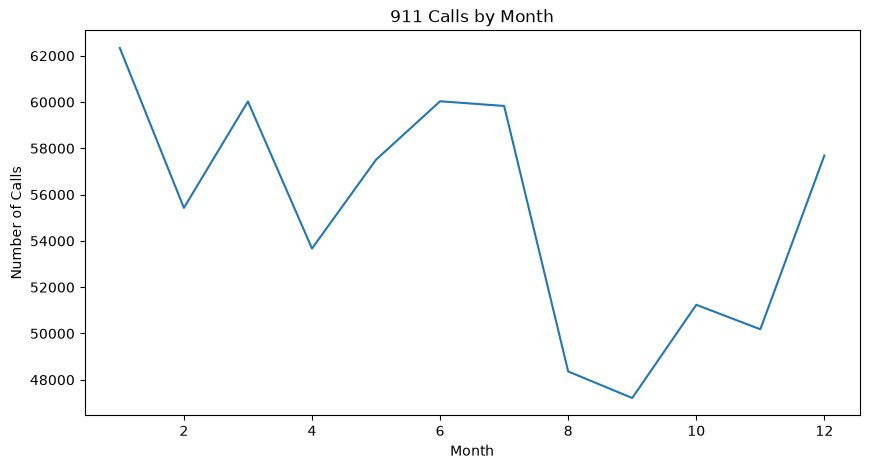

In [13]:
monthly_calls = df.groupby('Month').size()

plt.figure(figsize=(10,5))
monthly_calls.plot()
plt.title("911 Calls by Month")
plt.xlabel("Month")
plt.ylabel("Number of Calls")
plt.show()


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/911.csv")

df.head()

,lat,lng,desc,zip,title,timeStamp,twp,addr,e
0,40.297876,-75.581294,REINDEER CT & DEAD END; NEW HANOVER; Station ...,19525.0,EMS: BACK PAINS/INJURY,2015-12-10 17:10:52,NEW HANOVER,REINDEER CT & DEAD END,1
1,40.258061,-75.264680,BRIAR PATH & WHITEMARSH LN; HATFIELD TOWNSHIP...,19446.0,EMS: DIABETIC EMERGENCY,2015-12-10 17:29:21,HATFIELD TOWNSHIP,BRIAR PATH & WHITEMARSH LN,1
2,40.121182,-75.351975,HAWS AVE; NORRISTOWN; 2015-12-10 @ 14:39:21-St...,19401.0,Fire: GAS-ODOR/LEAK,2015-12-10 14:39:21,NORRISTOWN,HAWS AVE,1
3,40.116153,-75.343513,AIRY ST & SWEDE ST; NORRISTOWN; Station 308A;...,19401.0,EMS: CARDIAC EMERGENCY,2015-12-10 16:47:36,NORRISTOWN,AIRY ST & SWEDE ST,1
4,40.251492,-75.603350,CHERRYWOOD CT & DEAD END; LOWER POTTSGROVE; S...,NaN,EMS: DIZZINESS,2015-12-10 16:56:52,LOWER POTTSGROVE,CHERRYWOOD CT & DEAD END,1
